[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module2/0_BinaryClassification_Titanic_structured_data.ipynb)

🔴
<!-- 🎙 DAVE TALKING POINTS (invisible when rendered - double-click to read):
Video 12 (M2.3) - Titanic: prep and the baseline to beat

- New question, same skeleton: who survives? Binary classification with a network.
- The wrangling IS the lesson: drop cabin (too missing), impute age with the mean, drop 2 missing embarked rows, LabelEncoder sex/embarked - dot products need numbers.
- THE BASELINE: 61.7% die - so a model predicting 'everyone dies' scores 61.7% with zero skill. Any real model must beat the majority class. Say this hard; it's the M1 accuracy lesson wearing a costume.
-->

# Classification with DNNs: Titanic
-------------------------------
**Dr. Dave Wanik**

Can you predict whether someone will survive the Titanic or not?

A description of the data can be found here: https://www.kaggle.com/c/titanic/data

In [1]:
# modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

!pip install scikeras
from scikeras.wrappers import KerasClassifier # updated 2023
#from keras.wrappers.scikit_learn import KerasClassifier
#from keras.utils import np_utils

# for modeling
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\dww05002\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## EDA
Read in the data, check for missing values, some interesting plots.

In [2]:
# # read data from github
# df = pd.read_csv('https://raw.githubusercontent.com/agconti/kaggle-titanic/master/data/train.csv')

In [3]:
# # read from shareable link
# # https://drive.google.com/file/d/1-sfX5y1olZm7_0iZcY1-mP2LyvTTcaNH/view?usp=sharing
# !gdown 1-sfX5y1olZm7_0iZcY1-mP2LyvTTcaNH
# df = pd.read_csv('../data/titanic_train.csv')

In [4]:
# Link to the data file on Github
url = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/refs/heads/main/OPIM5509_Module2_Files/data/titanic_train.csv"

# retrieve the data and build a dataframe
df = pd.read_csv(url)

df.shape

(891, 12)

In [5]:
# check for missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [6]:
# for simplicity, we will impute AGE with the mean, and delete the cabin column,
# then delete any rows with missing values (should only be from 'Embarked')

# first, delete the cabin column
df.drop(['Cabin'], axis=1, inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 111.1 KB


In [7]:
# now impute the 'Age' column - assign the result back!
# (inplace fillna on a single column no longer writes through in modern pandas)
df['Age'] = df['Age'].fillna(df['Age'].mean())
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 111.1 KB


In [8]:
# now ditch the two rows from 'Embarked'
df.dropna(inplace=True)

In [9]:
# voila! 889 rows.
df.info()

# now let's clean up the test data

<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    str    
 4   Sex          889 non-null    str    
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    str    
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 118.0 KB


In [10]:
# check out the test data for missing values
df.info()

<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    str    
 4   Sex          889 non-null    str    
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    str    
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 118.0 KB


In [11]:
# check out the data
df.head()

# we see PassengerID, Name and Ticket probably aren't useful,
# and that the Sex and Embarked column needs to get recoded into a number

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [12]:
# drop unncessary columns from train and testdf
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

# recode the sex column - assign the result back!
# (inplace replace on a single column no longer writes through in modern pandas)
df['Sex'] = df['Sex'].replace(('male', 'female'), (0, 1))

# recode the embarked column
df['Embarked'] = df['Embarked'].replace(('Q', 'S', 'C'), (0, 1, 2))

# check your work - great! ready for modeling.
print(df.info())
df.head()

<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  889 non-null    int64  
 1   Pclass    889 non-null    int64  
 2   Sex       889 non-null    object 
 3   Age       889 non-null    float64
 4   SibSp     889 non-null    int64  
 5   Parch     889 non-null    int64  
 6   Fare      889 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 62.5+ KB
None


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,1
1,1,1,1,38.0,1,0,71.2833,2
2,1,3,1,26.0,0,0,7.9250,1
3,1,1,1,35.0,1,0,53.1000,1
4,0,3,0,35.0,0,0,8.0500,1


In [13]:
# check your work - great! ready for modeling.
print(df.info())
df.head()

<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  889 non-null    int64  
 1   Pclass    889 non-null    int64  
 2   Sex       889 non-null    object 
 3   Age       889 non-null    float64
 4   SibSp     889 non-null    int64  
 5   Parch     889 non-null    int64  
 6   Fare      889 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 62.5+ KB
None


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,1
1,1,1,1,38.0,1,0,71.2833,2
2,1,3,1,26.0,0,0,7.9250,1
3,1,1,1,35.0,1,0,53.1000,1
4,0,3,0,35.0,0,0,8.0500,1


In [14]:
# check distribution of target variable
df['Survived'].value_counts()

Survived
0    549
1    340
Name: count, dtype: int64

In [15]:
# if your model is smart, it should have an accuracy better
# than a dummy model (that just predicts the majority class)
(549/(549+340))

0.6175478065241845

## Split Data into X and Y

In [16]:
# split into X and Y
Y = df['Survived']
X = df.drop(['Survived'], axis=1)

print(X.shape)
print(Y.shape)

(889, 7)
(889,)


In [17]:
# convert to numpy arrays - and force a real numeric dtype.
# Keras 3 refuses object-dtype arrays that older versions quietly coerced.
X = np.array(X).astype('float32')
Y = np.array(Y).astype('float32')

## Train/Test Split - the honest yardstick

If we train on ALL the data and then grade the model on that same data, we graded it on questions it already saw. So BEFORE we build anything: lock 20% of the rows in a vault. The model never trains on them - they exist only to answer one question at the end... *does this thing generalize?*

In [18]:
# hold out a REAL test set - 20% goes in the vault
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y,
                                                    test_size=0.2,
                                                    random_state=123)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(711, 7) (711,)
(178, 7) (178,)


🔴
<!-- 🎙 DAVE TALKING POINTS (invisible when rendered - double-click to read):
Video 13 (M2.3) - Titanic: train/test split, sigmoid, binary_crossentropy, confusion matrix

- NEW FIRST BEAT: lock 20% in the test vault BEFORE building anything. If we grade the model on rows it trained on, we graded it on questions it already saw. train_test_split, random_state so it's repeatable.
- Two changes from regression and ONLY two: output = Dense(1, sigmoid), loss = binary_crossentropy. Everything else identical.
- The sigmoid squishes to a 0-1 PROBABILITY - the exact predict_proba idea from M1, now coming out of a network. Threshold at 0.5 to get a class.
- binary_crossentropy rewards confident correct predictions and punishes confident wrong ones.
- validation_split now carves 20% out of the TRAINING partition - the vault stays sealed until the very end.
- Fresh-start cell before the callbacks fit: re-running fit CONTINUES training, so rebuild for a fair comparison.
- Confusion matrix + report on X_test ONLY -> high 70s/low 80s, beats the 61.7% baseline. Read precision vs recall in Titanic terms.
- CAREFUL on AUC if you mention it: high AUC = good class SEPARATION. (Do not repeat the M1 video 9 slip.)
-->

## Build a Model - no callbacks
Let's build a dense neural network!

In [19]:
# build a model
model = Sequential()
model.add(Dense(16, input_shape=(X_train.shape[1],), activation='relu')) # don't forget to add an input shape! (features,)
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417 (1.63 KB)

 Trainable params: 417 (1.63 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# compile the model
model.compile(optimizer='Adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [21]:
# fit the model - on the TRAINING partition only!
history = model.fit(X_train,
                    y_train,
                    epochs=80,
                    batch_size=10,
                    validation_split=0.2, # carved out of the TRAINING data - the test vault stays sealed!
                    shuffle=True)

Epoch 1/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 55s 999ms/step - accuracy: 0.7000 - loss: 1.3089

34/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6441 - loss: 1.3785   

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6479 - loss: 1.1825 - val_accuracy: 0.6713 - val_loss: 0.7093


Epoch 2/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.6000 - loss: 1.5443

45/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6822 - loss: 0.6969 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6743 - loss: 0.6895 - val_accuracy: 0.6923 - val_loss: 0.6326


Epoch 3/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8000 - loss: 0.4380

44/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6727 - loss: 0.6305 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6778 - loss: 0.6290 - val_accuracy: 0.7483 - val_loss: 0.6447


Epoch 4/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9000 - loss: 0.4219

38/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6974 - loss: 0.6082 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7007 - loss: 0.6237 - val_accuracy: 0.6853 - val_loss: 0.7108


Epoch 5/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.7000 - loss: 0.4664

39/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7077 - loss: 0.6048 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7025 - loss: 0.6151 - val_accuracy: 0.6923 - val_loss: 0.6326


Epoch 6/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.7000 - loss: 0.5001

40/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7025 - loss: 0.6006 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6937 - loss: 0.6097 - val_accuracy: 0.7133 - val_loss: 0.6114


Epoch 7/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.5000 - loss: 0.9457

44/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7182 - loss: 0.5949 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7201 - loss: 0.5778 - val_accuracy: 0.7483 - val_loss: 0.5989


Epoch 8/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6000 - loss: 0.7969

37/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7270 - loss: 0.5764 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7254 - loss: 0.5840 - val_accuracy: 0.7483 - val_loss: 0.5757


Epoch 9/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8000 - loss: 0.5306

36/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7167 - loss: 0.5817 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7113 - loss: 0.5926 - val_accuracy: 0.7133 - val_loss: 0.6740


Epoch 10/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6000 - loss: 0.5704

31/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7387 - loss: 0.5589 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7201 - loss: 0.5949 - val_accuracy: 0.6993 - val_loss: 0.6923


Epoch 11/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7000 - loss: 0.6635

34/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7324 - loss: 0.5886 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7271 - loss: 0.5892 - val_accuracy: 0.7203 - val_loss: 0.6174


Epoch 12/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8000 - loss: 0.4945

44/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7295 - loss: 0.5377 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7394 - loss: 0.5412 - val_accuracy: 0.7133 - val_loss: 0.6315


Epoch 13/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9000 - loss: 0.4560

34/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7294 - loss: 0.5712 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7359 - loss: 0.5482 - val_accuracy: 0.7343 - val_loss: 0.5431


Epoch 14/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8000 - loss: 0.4406

42/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7500 - loss: 0.5454 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7430 - loss: 0.5504 - val_accuracy: 0.7902 - val_loss: 0.5569


Epoch 15/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 1.0000 - loss: 0.1429

44/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7386 - loss: 0.5371 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7430 - loss: 0.5371 - val_accuracy: 0.7343 - val_loss: 0.5398


Epoch 16/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5000 - loss: 0.7609

34/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7265 - loss: 0.5666 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7658 - loss: 0.5180 - val_accuracy: 0.7343 - val_loss: 0.5394


Epoch 17/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8000 - loss: 0.5073

30/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7500 - loss: 0.5247 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7518 - loss: 0.5206 - val_accuracy: 0.7622 - val_loss: 0.5256


Epoch 18/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5000 - loss: 0.8830

30/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7667 - loss: 0.5271 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7658 - loss: 0.5050 - val_accuracy: 0.7273 - val_loss: 0.5198


Epoch 19/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9000 - loss: 0.4004

30/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7567 - loss: 0.5172 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7676 - loss: 0.5202 - val_accuracy: 0.7552 - val_loss: 0.5080


Epoch 20/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7000 - loss: 0.4508

34/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7676 - loss: 0.5003 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7676 - loss: 0.5017 - val_accuracy: 0.7343 - val_loss: 0.5152


Epoch 21/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 1.0000 - loss: 0.3137

40/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7575 - loss: 0.4980 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7518 - loss: 0.5157 - val_accuracy: 0.7413 - val_loss: 0.5199


Epoch 22/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8000 - loss: 0.4344

41/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7585 - loss: 0.5137 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7746 - loss: 0.4991 - val_accuracy: 0.7343 - val_loss: 0.5074


Epoch 23/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7000 - loss: 0.5871

34/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8176 - loss: 0.4549 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7905 - loss: 0.4754 - val_accuracy: 0.7343 - val_loss: 0.5184


Epoch 24/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6000 - loss: 0.6722

36/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7750 - loss: 0.4749 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7782 - loss: 0.4723 - val_accuracy: 0.7343 - val_loss: 0.4940


Epoch 25/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7000 - loss: 0.5362

33/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7970 - loss: 0.4585 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7817 - loss: 0.4695 - val_accuracy: 0.7413 - val_loss: 0.4914


Epoch 26/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6000 - loss: 0.4512

37/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7892 - loss: 0.4537 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7799 - loss: 0.4689 - val_accuracy: 0.7622 - val_loss: 0.5371


Epoch 27/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9000 - loss: 0.4367

43/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7744 - loss: 0.4820 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7852 - loss: 0.4688 - val_accuracy: 0.7552 - val_loss: 0.4857


Epoch 28/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8000 - loss: 0.3430

34/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7853 - loss: 0.4731 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7711 - loss: 0.4944 - val_accuracy: 0.7622 - val_loss: 0.5596


Epoch 29/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9000 - loss: 0.3418

42/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7786 - loss: 0.5024 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7887 - loss: 0.4838 - val_accuracy: 0.7832 - val_loss: 0.4738


Epoch 30/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8000 - loss: 0.4136

28/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8357 - loss: 0.4625 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8169 - loss: 0.4576 - val_accuracy: 0.7692 - val_loss: 0.4838


Epoch 31/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7000 - loss: 0.6042

33/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8273 - loss: 0.4570 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8011 - loss: 0.4569 - val_accuracy: 0.7343 - val_loss: 0.4912


Epoch 32/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 1.0000 - loss: 0.1883

36/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7944 - loss: 0.4669 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8028 - loss: 0.4578 - val_accuracy: 0.7413 - val_loss: 0.4998


Epoch 33/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9000 - loss: 0.4264

36/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8028 - loss: 0.4534 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7887 - loss: 0.4769 - val_accuracy: 0.7762 - val_loss: 0.4633


Epoch 34/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8000 - loss: 0.5584

47/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7872 - loss: 0.4659 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7975 - loss: 0.4518 - val_accuracy: 0.7692 - val_loss: 0.4694


Epoch 35/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 1.0000 - loss: 0.2197

39/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8077 - loss: 0.4222 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7975 - loss: 0.4401 - val_accuracy: 0.7692 - val_loss: 0.5033


Epoch 36/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.7000 - loss: 0.5233

54/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8148 - loss: 0.4469 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8046 - loss: 0.4572 - val_accuracy: 0.7762 - val_loss: 0.5476


Epoch 37/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9000 - loss: 0.2968

41/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8098 - loss: 0.4365 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8063 - loss: 0.4382 - val_accuracy: 0.7692 - val_loss: 0.4930


Epoch 38/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8000 - loss: 0.4493

34/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8059 - loss: 0.4517 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8099 - loss: 0.4457 - val_accuracy: 0.7902 - val_loss: 0.4781


Epoch 39/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8000 - loss: 0.3268

31/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8129 - loss: 0.4485 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8222 - loss: 0.4306 - val_accuracy: 0.7622 - val_loss: 0.4936


Epoch 40/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.7000 - loss: 0.5374

33/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8394 - loss: 0.4160 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8187 - loss: 0.4453 - val_accuracy: 0.7762 - val_loss: 0.4978


Epoch 41/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.5000 - loss: 0.8923

37/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7811 - loss: 0.4707 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8011 - loss: 0.4421 - val_accuracy: 0.7832 - val_loss: 0.4683


Epoch 42/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8000 - loss: 0.3666

38/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8026 - loss: 0.4416 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8116 - loss: 0.4385 - val_accuracy: 0.7832 - val_loss: 0.4620


Epoch 43/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 1.0000 - loss: 0.1148

31/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8355 - loss: 0.4231 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8099 - loss: 0.4374 - val_accuracy: 0.7622 - val_loss: 0.4673


Epoch 44/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6000 - loss: 0.7094

36/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7861 - loss: 0.4508 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8099 - loss: 0.4341 - val_accuracy: 0.7902 - val_loss: 0.4813


Epoch 45/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7000 - loss: 0.3840

30/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8000 - loss: 0.4498 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8063 - loss: 0.4420 - val_accuracy: 0.7762 - val_loss: 0.4759


Epoch 46/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9000 - loss: 0.3443

21/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8190 - loss: 0.4070 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7835 - loss: 0.4386 - val_accuracy: 0.7692 - val_loss: 0.4978


Epoch 47/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8000 - loss: 0.4260

32/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8250 - loss: 0.4194 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8187 - loss: 0.4315 - val_accuracy: 0.7622 - val_loss: 0.4672


Epoch 48/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9000 - loss: 0.2602

33/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7848 - loss: 0.4634 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8063 - loss: 0.4287 - val_accuracy: 0.7902 - val_loss: 0.4750


Epoch 49/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9000 - loss: 0.4472

35/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8057 - loss: 0.4216 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8046 - loss: 0.4358 - val_accuracy: 0.7692 - val_loss: 0.4746


Epoch 50/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6000 - loss: 0.7994

33/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7727 - loss: 0.4933 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7993 - loss: 0.4536 - val_accuracy: 0.7762 - val_loss: 0.4876


Epoch 51/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9000 - loss: 0.2853

37/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7838 - loss: 0.4433 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7817 - loss: 0.4382 - val_accuracy: 0.7762 - val_loss: 0.4750


Epoch 52/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8000 - loss: 0.6030

52/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7885 - loss: 0.4433 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7958 - loss: 0.4370 - val_accuracy: 0.7972 - val_loss: 0.4721


Epoch 53/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8000 - loss: 0.5101

30/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8033 - loss: 0.4615 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8028 - loss: 0.4407 - val_accuracy: 0.7832 - val_loss: 0.4859


Epoch 54/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.8000 - loss: 0.4804

40/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7775 - loss: 0.4471 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7940 - loss: 0.4298 - val_accuracy: 0.7552 - val_loss: 0.4748


Epoch 55/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.6000 - loss: 0.5302

35/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8000 - loss: 0.4614 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8063 - loss: 0.4329 - val_accuracy: 0.8042 - val_loss: 0.4520


Epoch 56/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8000 - loss: 0.4932

32/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8094 - loss: 0.4092 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7993 - loss: 0.4324 - val_accuracy: 0.7552 - val_loss: 0.4947


Epoch 57/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6000 - loss: 0.9305

30/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8067 - loss: 0.4560 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8345 - loss: 0.4282 - val_accuracy: 0.7762 - val_loss: 0.4972


Epoch 58/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8000 - loss: 0.3207

18/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8333 - loss: 0.3705

49/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8122 - loss: 0.4167

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8081 - loss: 0.4259 - val_accuracy: 0.7832 - val_loss: 0.4642


Epoch 59/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7000 - loss: 0.4116

34/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8059 - loss: 0.4213 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8099 - loss: 0.4367 - val_accuracy: 0.7762 - val_loss: 0.4692


Epoch 60/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9000 - loss: 0.3204

32/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8344 - loss: 0.4206 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8239 - loss: 0.4285 - val_accuracy: 0.7622 - val_loss: 0.5704


Epoch 61/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.8000 - loss: 0.4258

40/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7975 - loss: 0.4518 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8028 - loss: 0.4242 - val_accuracy: 0.7692 - val_loss: 0.4918


Epoch 62/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.7000 - loss: 0.5224

35/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7657 - loss: 0.4930 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7923 - loss: 0.4643 - val_accuracy: 0.7762 - val_loss: 0.4637


Epoch 63/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8000 - loss: 0.6583

36/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8111 - loss: 0.4474 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8187 - loss: 0.4285 - val_accuracy: 0.7832 - val_loss: 0.4574


Epoch 64/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8000 - loss: 0.3013

42/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8310 - loss: 0.4212 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8239 - loss: 0.4260 - val_accuracy: 0.7972 - val_loss: 0.4704


Epoch 65/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.6000 - loss: 0.7164

42/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8048 - loss: 0.4359 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8028 - loss: 0.4301 - val_accuracy: 0.7692 - val_loss: 0.4999


Epoch 66/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6000 - loss: 0.6685

29/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8241 - loss: 0.4112 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7993 - loss: 0.4461 - val_accuracy: 0.7692 - val_loss: 0.4778


Epoch 67/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7000 - loss: 0.6071

46/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8130 - loss: 0.4192 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8099 - loss: 0.4187 - val_accuracy: 0.7972 - val_loss: 0.4614


Epoch 68/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7000 - loss: 0.7277

38/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8237 - loss: 0.4017 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8063 - loss: 0.4345 - val_accuracy: 0.7832 - val_loss: 0.5106


Epoch 69/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9000 - loss: 0.3980

39/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8000 - loss: 0.4340 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8028 - loss: 0.4276 - val_accuracy: 0.7552 - val_loss: 0.4903


Epoch 70/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7000 - loss: 0.4842

27/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8185 - loss: 0.4299 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8116 - loss: 0.4217 - val_accuracy: 0.7902 - val_loss: 0.4671


Epoch 71/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8000 - loss: 0.2777

44/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8000 - loss: 0.4403 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8151 - loss: 0.4287 - val_accuracy: 0.7692 - val_loss: 0.4856


Epoch 72/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8000 - loss: 0.4201

46/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8152 - loss: 0.4069 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8116 - loss: 0.4218 - val_accuracy: 0.7692 - val_loss: 0.4958


Epoch 73/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7000 - loss: 0.5542

32/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7969 - loss: 0.4705 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8099 - loss: 0.4333 - val_accuracy: 0.7902 - val_loss: 0.4752


Epoch 74/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9000 - loss: 0.3654

52/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8173 - loss: 0.4288 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8116 - loss: 0.4292 - val_accuracy: 0.7972 - val_loss: 0.4589


Epoch 75/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.8000 - loss: 0.2860

37/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7919 - loss: 0.4678 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8134 - loss: 0.4234 - val_accuracy: 0.7483 - val_loss: 0.5004


Epoch 76/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 1.0000 - loss: 0.1838

37/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7892 - loss: 0.4473 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8046 - loss: 0.4262 - val_accuracy: 0.8112 - val_loss: 0.4660


Epoch 77/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 1.0000 - loss: 0.2002

28/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8214 - loss: 0.4129 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8134 - loss: 0.4148 - val_accuracy: 0.7692 - val_loss: 0.4687


Epoch 78/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8000 - loss: 0.3582

33/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8242 - loss: 0.3911 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8081 - loss: 0.4257 - val_accuracy: 0.8112 - val_loss: 0.4580


Epoch 79/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9000 - loss: 0.2410

33/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8061 - loss: 0.4248 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8204 - loss: 0.4188 - val_accuracy: 0.7832 - val_loss: 0.4665


Epoch 80/80


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9000 - loss: 0.3822

46/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7978 - loss: 0.4441 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8063 - loss: 0.4276 - val_accuracy: 0.7622 - val_loss: 0.4625


In [22]:
# now you could plot the epochs and train for exactly that many...
# but callbacks and early stopping are way better!
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

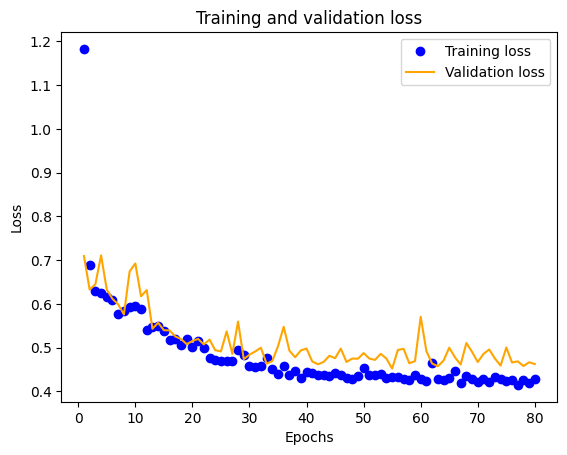

In [23]:
# can paste in learning curve code from previous examples
# just need to update dictionary keys to accuracy etc.

# let's see the training and validation loss by epoch
history_dict = history.history
loss_values = history_dict['loss'] # you can change this
val_loss_values = history_dict['val_loss'] # you can also change this
epochs = range(1, len(loss_values) + 1) # range of X (no. of epochs)
plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'orange', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

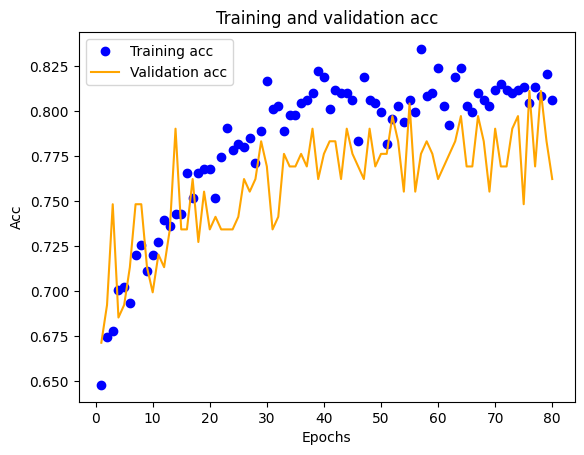

In [24]:
# let's see the training and validation accuracy by epoch
history_dict = history.history
loss_values = history_dict['accuracy'] # you can change this
val_loss_values = history_dict['val_accuracy'] # you can also change this
epochs = range(1, len(loss_values) + 1) # range of X (no. of epochs)
plt.plot(epochs, loss_values, 'bo', label='Training acc')
plt.plot(epochs, val_loss_values, 'orange', label='Validation acc')
plt.title('Training and validation acc')
plt.xlabel('Epochs')
plt.ylabel('Acc')
plt.legend()
plt.show()

## Build a Model - with callbacks
Let's introduce early stopping, we could also introduce some weight regularization then revisualization our network.

Link: https://keras.io/api/callbacks/early_stopping/

In [25]:
# fresh start! clear the old model and rebuild from scratch
# gotcha: re-running fit on an existing model CONTINUES training from
# wherever it left off... great for resuming, terrible for a fair comparison!
import keras
keras.backend.clear_session()

model = Sequential()
model.add(Dense(16, input_shape=(X_train.shape[1],), activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='Adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [26]:
# we will keep the same model architecture as before,
# but we will make this a little simpler...

# early stopping callback
# This callback will stop the training when there is no improvement in
# the validation loss for 10 consecutive epochs.
es = EarlyStopping(monitor='val_accuracy',
                                   mode='max', # don't minimize the accuracy!
                                   patience=20,
                                   restore_best_weights=True)

# now we just update our model fit call
history = model.fit(X_train,
                    y_train,
                    callbacks=[es],
                    epochs=1000, # you can set this to a big number!
                    batch_size=10,
                    validation_split=0.2,
                    shuffle=True,
                    verbose=1)

Epoch 1/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 49s 879ms/step - accuracy: 0.3000 - loss: 2.0981

30/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6633 - loss: 0.8416   

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6725 - loss: 0.7295 - val_accuracy: 0.6853 - val_loss: 0.6229


Epoch 2/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8000 - loss: 0.5487

37/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6459 - loss: 0.6572 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6866 - loss: 0.6206 - val_accuracy: 0.7413 - val_loss: 0.5951


Epoch 3/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5000 - loss: 0.8842

42/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7119 - loss: 0.5705 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7130 - loss: 0.6062 - val_accuracy: 0.6783 - val_loss: 0.6067


Epoch 4/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.8000 - loss: 0.5059

32/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7312 - loss: 0.5834 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7130 - loss: 0.6050 - val_accuracy: 0.7483 - val_loss: 0.5706


Epoch 5/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.4000 - loss: 0.7586

36/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7139 - loss: 0.6030 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7130 - loss: 0.6064 - val_accuracy: 0.7413 - val_loss: 0.5529


Epoch 6/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8000 - loss: 0.8352

42/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7190 - loss: 0.5685 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7201 - loss: 0.5567 - val_accuracy: 0.7622 - val_loss: 0.5493


Epoch 7/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.8000 - loss: 0.4241

37/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7459 - loss: 0.5655 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7447 - loss: 0.5547 - val_accuracy: 0.7622 - val_loss: 0.5217


Epoch 8/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7000 - loss: 0.5821

26/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7731 - loss: 0.5213 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7447 - loss: 0.5302 - val_accuracy: 0.7622 - val_loss: 0.5168


Epoch 9/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7000 - loss: 0.5056

27/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7481 - loss: 0.5250 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7465 - loss: 0.5369 - val_accuracy: 0.7343 - val_loss: 0.5313


Epoch 10/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8000 - loss: 0.4116

56/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7250 - loss: 0.5534 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7289 - loss: 0.5504 - val_accuracy: 0.7622 - val_loss: 0.4953


Epoch 11/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.8000 - loss: 0.4221

38/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7632 - loss: 0.5174 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7588 - loss: 0.5093 - val_accuracy: 0.7762 - val_loss: 0.4937


Epoch 12/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9000 - loss: 0.4312

36/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7806 - loss: 0.4826 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7535 - loss: 0.5136 - val_accuracy: 0.7692 - val_loss: 0.5025


Epoch 13/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8000 - loss: 0.5330

36/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7611 - loss: 0.4995 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7553 - loss: 0.5159 - val_accuracy: 0.7622 - val_loss: 0.5016


Epoch 14/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 1.0000 - loss: 0.3010

34/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7618 - loss: 0.5178 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7835 - loss: 0.5024 - val_accuracy: 0.7762 - val_loss: 0.4749


Epoch 15/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9000 - loss: 0.5768

34/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7853 - loss: 0.4865 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7852 - loss: 0.4842 - val_accuracy: 0.7762 - val_loss: 0.4726


Epoch 16/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8000 - loss: 0.4801

30/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7667 - loss: 0.4876 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7694 - loss: 0.4909 - val_accuracy: 0.7622 - val_loss: 0.5028


Epoch 17/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8000 - loss: 0.4405

35/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7629 - loss: 0.4971 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7641 - loss: 0.5009 - val_accuracy: 0.7622 - val_loss: 0.4564


Epoch 18/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8000 - loss: 0.3680

54/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8056 - loss: 0.4736 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8063 - loss: 0.4747 - val_accuracy: 0.7692 - val_loss: 0.4536


Epoch 19/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6000 - loss: 0.7168

33/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8212 - loss: 0.4757 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7852 - loss: 0.4830 - val_accuracy: 0.7832 - val_loss: 0.4561


Epoch 20/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8000 - loss: 0.3550

44/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8091 - loss: 0.4479 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7958 - loss: 0.4658 - val_accuracy: 0.7902 - val_loss: 0.4585


Epoch 21/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9000 - loss: 0.3801

50/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7760 - loss: 0.4885 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7764 - loss: 0.4881 - val_accuracy: 0.7692 - val_loss: 0.4526


Epoch 22/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8000 - loss: 0.2746

36/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8083 - loss: 0.4503 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8081 - loss: 0.4584 - val_accuracy: 0.7622 - val_loss: 0.5578


Epoch 23/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6000 - loss: 0.6538

34/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8029 - loss: 0.4864 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8011 - loss: 0.4749 - val_accuracy: 0.7832 - val_loss: 0.4597


Epoch 24/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6000 - loss: 0.5897

40/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7900 - loss: 0.5052 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7993 - loss: 0.4773 - val_accuracy: 0.7692 - val_loss: 0.4732


Epoch 25/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9000 - loss: 0.5571

31/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8258 - loss: 0.4498 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8116 - loss: 0.4643 - val_accuracy: 0.7972 - val_loss: 0.4481


Epoch 26/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8000 - loss: 0.3869

29/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8310 - loss: 0.4177 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7923 - loss: 0.4835

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7923 - loss: 0.4835 - val_accuracy: 0.7832 - val_loss: 0.4983


Epoch 27/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.8000 - loss: 0.4929

37/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7946 - loss: 0.4722 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8099 - loss: 0.4496 - val_accuracy: 0.8042 - val_loss: 0.4369


Epoch 28/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 1.0000 - loss: 0.1980

33/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7818 - loss: 0.4819 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8081 - loss: 0.4543 - val_accuracy: 0.7692 - val_loss: 0.4683


Epoch 29/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 1.0000 - loss: 0.1871

41/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8049 - loss: 0.4582 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8081 - loss: 0.4558 - val_accuracy: 0.7972 - val_loss: 0.4342


Epoch 30/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.8000 - loss: 0.5450

47/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8128 - loss: 0.4573 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8134 - loss: 0.4439 - val_accuracy: 0.8042 - val_loss: 0.4444


Epoch 31/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8000 - loss: 0.5155

35/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7971 - loss: 0.4672 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8116 - loss: 0.4611 - val_accuracy: 0.7762 - val_loss: 0.4534


Epoch 32/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8000 - loss: 0.5276

38/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8158 - loss: 0.4286 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8081 - loss: 0.4465 - val_accuracy: 0.7762 - val_loss: 0.4620


Epoch 33/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8000 - loss: 0.5105

38/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8316 - loss: 0.4229 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8134 - loss: 0.4405 - val_accuracy: 0.7832 - val_loss: 0.4481


Epoch 34/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9000 - loss: 0.4195

35/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8400 - loss: 0.4138 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8275 - loss: 0.4329 - val_accuracy: 0.7832 - val_loss: 0.4713


Epoch 35/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8000 - loss: 0.5670

38/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8421 - loss: 0.3858 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8169 - loss: 0.4283 - val_accuracy: 0.7902 - val_loss: 0.4755


Epoch 36/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8000 - loss: 0.3115

37/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8000 - loss: 0.4334 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8046 - loss: 0.4406 - val_accuracy: 0.7692 - val_loss: 0.4698


Epoch 37/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9000 - loss: 0.3364

36/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8056 - loss: 0.4583 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8169 - loss: 0.4382 - val_accuracy: 0.7692 - val_loss: 0.4660


Epoch 38/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.8000 - loss: 0.3810

32/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7969 - loss: 0.4880 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8028 - loss: 0.4604 - val_accuracy: 0.7692 - val_loss: 0.4898


Epoch 39/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8000 - loss: 0.4591

30/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8433 - loss: 0.4024 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8116 - loss: 0.4439 - val_accuracy: 0.7762 - val_loss: 0.4751


Epoch 40/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.4000 - loss: 1.0419

25/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7960 - loss: 0.4638 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8222 - loss: 0.4281 - val_accuracy: 0.8042 - val_loss: 0.4297


Epoch 41/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8000 - loss: 0.3298

54/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8148 - loss: 0.4240 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8151 - loss: 0.4287 - val_accuracy: 0.7902 - val_loss: 0.4401


Epoch 42/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 1.0000 - loss: 0.1169

46/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8217 - loss: 0.4290 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8169 - loss: 0.4354 - val_accuracy: 0.7972 - val_loss: 0.4496


Epoch 43/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.9000 - loss: 0.3081

34/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8176 - loss: 0.4441 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8081 - loss: 0.4392 - val_accuracy: 0.7762 - val_loss: 0.5275


Epoch 44/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 1.0000 - loss: 0.2074

33/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7788 - loss: 0.5010 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8081 - loss: 0.4530 - val_accuracy: 0.8182 - val_loss: 0.4452


Epoch 45/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8000 - loss: 0.7882

31/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8097 - loss: 0.4457 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8116 - loss: 0.4390 - val_accuracy: 0.8042 - val_loss: 0.4328


Epoch 46/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8000 - loss: 0.6155

41/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8049 - loss: 0.4630 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8151 - loss: 0.4373 - val_accuracy: 0.7972 - val_loss: 0.4444


Epoch 47/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9000 - loss: 0.3742

40/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8475 - loss: 0.3987 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8275 - loss: 0.4224 - val_accuracy: 0.7762 - val_loss: 0.4497


Epoch 48/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8000 - loss: 0.3498

33/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8424 - loss: 0.3973 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8204 - loss: 0.4307 - val_accuracy: 0.7902 - val_loss: 0.4447


Epoch 49/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9000 - loss: 0.3259

41/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8049 - loss: 0.4558 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8169 - loss: 0.4341 - val_accuracy: 0.7902 - val_loss: 0.4469


Epoch 50/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9000 - loss: 0.3226

43/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8116 - loss: 0.4433 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8187 - loss: 0.4338 - val_accuracy: 0.8252 - val_loss: 0.4345


Epoch 51/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8000 - loss: 0.5005

33/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8091 - loss: 0.4404 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8151 - loss: 0.4322 - val_accuracy: 0.8252 - val_loss: 0.4411


Epoch 52/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8000 - loss: 0.6297

28/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8679 - loss: 0.3663 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8345 - loss: 0.4222 - val_accuracy: 0.7622 - val_loss: 0.4743


Epoch 53/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6000 - loss: 0.7150

27/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7926 - loss: 0.4486 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8028 - loss: 0.4404 - val_accuracy: 0.7972 - val_loss: 0.4456


Epoch 54/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9000 - loss: 0.2690

40/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8225 - loss: 0.4360 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8275 - loss: 0.4248 - val_accuracy: 0.7762 - val_loss: 0.4524


Epoch 55/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9000 - loss: 0.2952

37/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8351 - loss: 0.4092 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8257 - loss: 0.4227 - val_accuracy: 0.7622 - val_loss: 0.4841


Epoch 56/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.5000 - loss: 0.9112

37/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8027 - loss: 0.4535 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8116 - loss: 0.4480 - val_accuracy: 0.7762 - val_loss: 0.5695


Epoch 57/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step - accuracy: 1.0000 - loss: 0.1280

17/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8059 - loss: 0.5301

54/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8148 - loss: 0.4702

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8187 - loss: 0.4645 - val_accuracy: 0.7762 - val_loss: 0.5116


Epoch 58/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7000 - loss: 0.6039

36/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8194 - loss: 0.4316 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8134 - loss: 0.4303 - val_accuracy: 0.8112 - val_loss: 0.4529


Epoch 59/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9000 - loss: 0.2705

36/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8389 - loss: 0.4014 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8187 - loss: 0.4241 - val_accuracy: 0.7762 - val_loss: 0.4702


Epoch 60/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9000 - loss: 0.2884

36/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8000 - loss: 0.4351 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8187 - loss: 0.4184 - val_accuracy: 0.7902 - val_loss: 0.4376


Epoch 61/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8000 - loss: 0.4053

30/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8300 - loss: 0.4141 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8187 - loss: 0.4268 - val_accuracy: 0.7972 - val_loss: 0.4359


Epoch 62/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.1503

25/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8120 - loss: 0.4414 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8292 - loss: 0.4250 - val_accuracy: 0.8042 - val_loss: 0.4288


Epoch 63/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8000 - loss: 0.4579

36/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8278 - loss: 0.3959 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8134 - loss: 0.4199 - val_accuracy: 0.8112 - val_loss: 0.4503


Epoch 64/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8000 - loss: 0.3984

44/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8136 - loss: 0.4297 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8257 - loss: 0.4196 - val_accuracy: 0.7762 - val_loss: 0.4491


Epoch 65/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7000 - loss: 0.7358

45/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8067 - loss: 0.4451 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8116 - loss: 0.4362 - val_accuracy: 0.8042 - val_loss: 0.4277


Epoch 66/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9000 - loss: 0.2695

44/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8182 - loss: 0.4132 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8134 - loss: 0.4179 - val_accuracy: 0.7762 - val_loss: 0.4940


Epoch 67/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5000 - loss: 0.7270

43/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8163 - loss: 0.4213 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8239 - loss: 0.4192 - val_accuracy: 0.7762 - val_loss: 0.4573


Epoch 68/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9000 - loss: 0.3884

39/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8128 - loss: 0.4249 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8134 - loss: 0.4160 - val_accuracy: 0.7832 - val_loss: 0.4494


Epoch 69/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8000 - loss: 0.4291

42/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8190 - loss: 0.4249 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8151 - loss: 0.4434 - val_accuracy: 0.7832 - val_loss: 0.4413


Epoch 70/1000


 1/57 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7000 - loss: 0.6245

40/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8275 - loss: 0.4067 

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8169 - loss: 0.4393 - val_accuracy: 0.7972 - val_loss: 0.4504


## Evaluate the Model
Always check out the learning curve, show the TP, FP, TN, FN as well as the classification report.

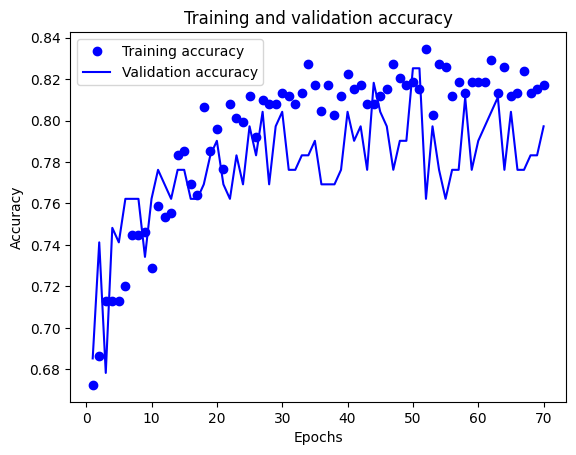

In [27]:
# learning curve
import matplotlib.pyplot as plt

# accuracy
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# loss
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, acc, 'bo', label='Training accuracy')
# b is for "solid blue line"
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [28]:
# this is the max value - should correspond to
# the HIGHEST train accuracy (go look at the verbose from the model fit)
np.max(val_acc)

np.float64(0.8251748085021973)

In [29]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [30]:
# see how these are numbers between 0 and 1? prob of successes (survival)
model.predict(X_test)

1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


array([[0.11666939],
       [0.03967811],
       [0.21223982],
       [0.10120834],
       [0.14454818],
       [0.17378703],
       [0.09563922],
       [0.767241  ],
       [0.06118412],
       [0.44783688],
       [0.10389829],
       [0.08271553],
       [0.8284198 ],
       [0.10202664],
       [0.14055368],
       [0.7691347 ],
       [0.07330783],
       [0.529235  ],
       [0.33042723],
       [0.71626496],
       [0.48801056],
       [0.2003954 ],
       [0.09931213],
       [0.78915405],
       [0.07067834],
       [0.09170415],
       [0.09170415],
       [0.17122814],
       [0.1070576 ],
       [0.3998134 ],
       [0.5170634 ],
       [0.7174299 ],
       [0.12069179],
       [0.07541537],
       [0.09195559],
       [0.07342613],
       [0.14022861],
       [0.5246588 ],
       [0.68482417],
       [0.10202056],
       [0.5769298 ],
       [0.06679652],
       [0.529235  ],
       [0.34886461],
       [0.52743566],
       [0.22108883],
       [0.24139832],
       [0.467

In [31]:
np.round(model.predict(X_test), 0)

1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],

In [32]:
# here is y_test
y_test

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0.,
       1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 1., 0., 1.,
       1., 0., 0., 1., 1., 0., 0., 0., 1., 1., 0., 0., 1., 0., 0., 0., 1.,
       0., 0., 0., 1., 1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 0., 0., 0.,
       1., 0., 1., 1., 1., 0., 0., 0., 1., 0., 1., 1., 0., 0., 1., 1., 0.,
       0., 0., 1., 1., 0., 1., 1., 1., 0., 1., 0., 1., 0., 0., 1., 1., 1.,
       0., 0., 0., 1., 0., 0., 0., 1., 1., 1., 1., 0., 0., 1., 0., 0., 1.,
       0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 1.,
       1., 0., 1., 0., 0., 1., 1., 0., 1., 0., 0., 0., 1., 1., 0., 0., 0.,
       0., 0., 0., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1., 0., 1., 0.,
       1., 0., 1., 0., 1., 0., 1., 0.], dtype=float32)

In [33]:
# see how the model did - ON DATA IT HAS NEVER SEEN!
# if you don't round to a whole number (0 or 1), the confusion matrix won't work!
preds = np.round(model.predict(X_test), 0)

# confusion matrix
confusion_matrix(y_test, preds) # order matters! (actual, predicted)

# TP is bottom right
# TN is top left
# FP is top right
# FN is bottom left

# look at documentation for conf matrix on sklearn if you have questions!

1/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


array([[94, 12],
       [23, 49]])

In [34]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

         0.0       0.80      0.89      0.84       106
         1.0       0.80      0.68      0.74        72

    accuracy                           0.80       178
   macro avg       0.80      0.78      0.79       178
weighted avg       0.80      0.80      0.80       178



# ⭐ On Your Own: push the split further!

This notebook now does it the RIGHT way: 20% locked in the vault before any model was built, both fits on `X_train` only (with `validation_split` carving the feedback signal out of the training partition), and the confusion matrix + classification report on `X_test` - rows the model has NEVER seen. That test number still has to beat the 62% dummy baseline... everything above it is what your network actually earned.

Now push it:
* Add `stratify=Y` to the split so both piles get the same 62/38 died/survived mix - then check `y_train.mean()` and `y_test.mean()` to prove it.
* Change the `random_state` a few times and re-run. Watch the test accuracy wiggle a couple points - one split is ONE lottery ticket.
* Want the cure for that wiggle? Two bonus notebooks: **Titanic Train/Val/Test** (a third pile, so early stopping gets its own partition) and **Titanic K-Fold** (five honest scores instead of one).

# Go Play!
* Shuffle the original dataframe
* Consider pre-processing your data (MinMaxScaling, PolynomialFeatures)
  * https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html
* Add more layers and change the number of hidden units
* Try to use 'tanh' instead of 'relu' and see how your results change.
* Try to use adam instead of rmsprop if you want (this includes a momentum term!), and customize it with other learning rates.
  * https://keras.io/api/optimizers/adam/
* Consider setting restore_best_weights=False and see how the confusion matrix changes.
* Try this on another dataset.